# Enhancing House Price Prediction using Advanced Ensemble Learning and Stacking Techniques
- **Course:** IS403.Q13 - Business Data Analysis
- **Institute:** University of Information Technology, VNU-HCM
- **Date:** December 2025

### **Team Members:**
| Name | Student ID | Email |
| :--- | :--- | :--- |
| **Thinh Vu** | 22521420 | 22521420@gm.uit.edu.vn |
| **Thinh Dinh** | 22521401 | 22521401@gm.uit.edu.vn |
| **Thanh Nguyen** | 22521352 | 22521352@gm.uit.edu.vn |

---

## 1. Research Objective & Context
This study aims to predict housing prices in Ames, Iowa, by leveraging
advanced ensemble learning techniques. The problem is formulated as a
regression task where the target variable is `SalePrice`.

**Key Challenges:**
* **High Dimensionality:** The dataset contains over 70 features (numerical
and categorical).
* **Multicollinearity:** Features like `GarageArea` and `GarageCars` are
highly correlated.
* **Outliers:** Specific properties (e.g., agricultural land) deviate
significantly from market trends.

**Proposed Solution:**
We propose a **Multi-Level Stacking Architecture** that combines the
robustness of regularized linear models with the non-linear predictive power
of gradient boosting machines.

## 2. Setup and Configuration
We import the necessary libraries for data manipulation, visualization, and
modeling. We also configure global settings to ensure reproducibility and
high-quality visual outputs suitable for academic reporting.

In [1]:
from scipy.stats import skew
import joblib
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Statistics
from scipy.stats import skew, norm
from scipy.special import boxcox1p

# Machine Learning
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor, VotingRegressor
from sklearn.base import BaseEstimator, RegressorMixin, clone

# Boosting Libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Configuration
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


## 3. Data Loading and Evaluation Strategy

### 3.1 Data Loading
We load the training and testing datasets. The `Id` column is removed from
the feature set as it contains no predictive information.

### 3.2 Evaluation Metric: RMSLE
Since housing prices span several orders of magnitude, absolute errors on
expensive houses would disproportionately penalize the model. Therefore, we
evaluate performance using **Root Mean Squared Logarithmic Error (RMSLE)**.

$$
\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(p_i + 1) - \log(a_i + 1))^2}
$$

**Implementation:** We apply `np.log1p` to the target variable (`SalePrice`)
during training. Consequently, minimizing standard RMSE on the
log-transformed target is mathematically equivalent to minimizing RMSLE on
the original scale.

In [2]:
# 3.1 Robust Path Handling
BASE_DIR = os.path.join("..", "data")
TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")

try:
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)
    print(f"Data Loaded. Train: {train.shape}, Test: {test.shape}")
except FileNotFoundError:
    print(f"ERROR: Could not find data at {os.path.abspath(BASE_DIR)}")

# 3.2 Save IDs and Drop
train_ID = train['Id']
test_ID = test['Id']
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

# 3.3 Define Evaluation Metric (RMSLE)
# We use 5-Fold Cross Validation
n_folds = 5
kf = KFold(n_folds, shuffle=True, random_state=42)


def rmse_cv(model, X, y):
    rmse = np.sqrt(-cross_val_score(model, X, y,
                   scoring="neg_mean_squared_error", cv=kf))
    return rmse

# 3.4 Define Custom Blender for CV (Statistically Valid Blend Score)
class CustomGeometricBlender(BaseEstimator, RegressorMixin):
    # Pass the unfitted model definitions and weights to the class
    def __init__(self, model1, model2, model3, w1=0.70, w2=0.15, w3=0.15):
        self.model1 = model1
        self.model2 = model2
        self.model3 = model3
        self.w1 = w1
        self.w2 = w2
        self.w3 = w3

    def fit(self, X, y):
        # Crucial step: Clone and train each component model on the training fold
        self.model1_ = clone(self.model1).fit(X, y)
        self.model2_ = clone(self.model2).fit(X, y)
        self.model3_ = clone(self.model3).fit(X, y)
        return self

    def predict(self, X):
        # Get predictions (in Log Space) from the trained models
        pred1 = self.model1_.predict(X)
        pred2 = self.model2_.predict(X)
        pred3 = self.model3_.predict(X)

        # Geometric Mean in Real Space = Weighted Mean in Log Space
        blend_pred = (self.w1 * pred1) + (self.w2 * pred2) + (self.w3 * pred3)
        return blend_pred


print("Evaluation function 'rmse_cv' and 'CustomGeometricBlender' ready.")

Data Loaded. Train: (1460, 81), Test: (1459, 80)
Evaluation function 'rmse_cv' and 'CustomGeometricBlender' ready.


## 4. Exploratory Data Analysis (EDA)
We perform a targeted analysis to prepare the data for modeling.

1.  **Target Normalization:** The original `SalePrice` is right-skewed. We
confirm that log-transformation normalizes the distribution, satisfying the
assumptions of linear regression.
2.  **Outlier Detection:** We visualize `GrLivArea` vs. `SalePrice` to
identify anomalies. As noted in the graph, houses with > 4000 sq. ft. but
low prices are outliers and should be removed to prevent skewing the model.

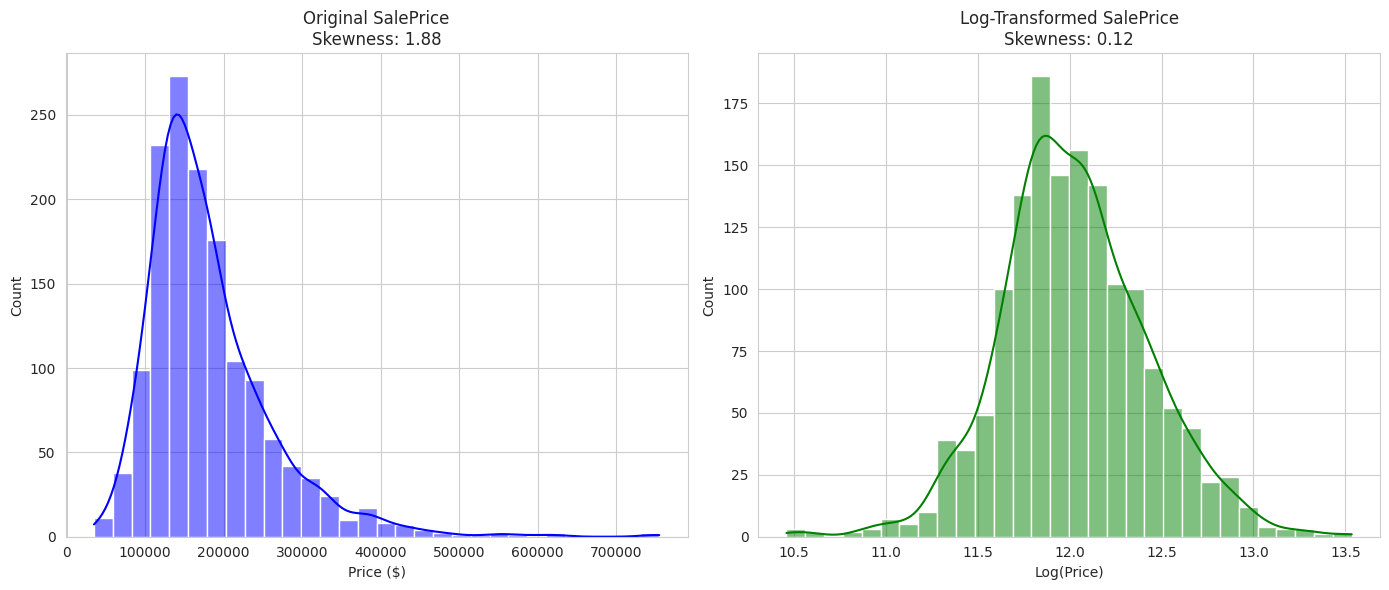

Observation: The log-transformation successfully reduced skewness, making the target variable approximate a normal distribution suitable for linear models.


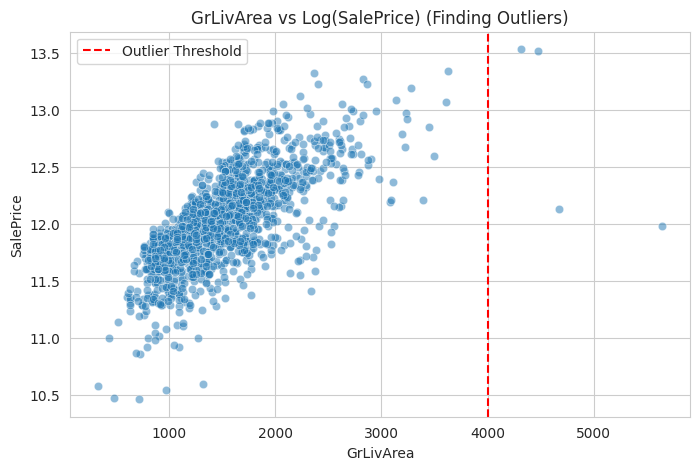

In [3]:
# 4.1 Target Variable Analysis: Before vs. After Transformation
plt.figure(figsize=(14, 6))

# Plot 1: Original Distribution (Skewed)
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, color='blue', bins=30)
plt.title(f"Original SalePrice\nSkewness: {train['SalePrice'].skew():.2f}")
plt.xlabel("Price ($)")

# Apply Log-Transformation
train["SalePrice"] = np.log1p(train["SalePrice"])
y_train = train.SalePrice.values

# Plot 2: Transformed Distribution (Normal)
plt.subplot(1, 2, 2)
sns.histplot(train['SalePrice'], kde=True, color='green', bins=30)
plt.title(
    f"Log-Transformed SalePrice\nSkewness: {train['SalePrice'].skew():.2f}")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()

print("Observation: The log-transformation successfully reduced skewness, making the target variable approximate a normal distribution suitable for linear models.")

# 4.2 Outlier Detection (GrLivArea)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', alpha=0.5)
plt.axvline(x=4000, color='r', linestyle='--', label='Outlier Threshold')
plt.title("GrLivArea vs Log(SalePrice) (Finding Outliers)")
plt.legend()
plt.show()

## 5. Data Preprocessing & Feature Engineering
Our preprocessing pipeline is designed to address the specific statistical
properties of the Ames dataset.

**5.1 Feature Engineering (Polynomials & Interactions)**
To capture non-linear value drivers, we synthesize new features:
* **TotalSF:** Sum of basement and living areas.
* **Interactions:** `TotalSF * OverallQual` captures the exponential value of
high-quality luxury space.
* **Polynomials:** Squared terms (`TotalSF^2`) allow the model to fit curved
relationships.

**5.2 Skewness Handling (Box-Cox)**
We identify skewed numerical features ($|skew| > 0.75$) and apply the
**Box-Cox transformation**. This stabilizes variance and improves the
performance of Lasso/Ridge.

**5.3 Hybrid Encoding**
To balance dimensionality with information retention, we employed a hybrid
strategy:
* **Label Encoding:** Used for ordinal features (e.g., `KitchenQual`) to
preserve the rank order.
* **One-Hot Encoding:** Used for nominal features (e.g., `Neighborhood`)
where no intrinsic order exists.

In [9]:
# 5.1 Outlier Removal
# We check if SalePrice is already log-transformed (max < 100) or raw (max > 100)
# to ensure we correctly identify the low-price outliers.
cutoff_price = 300000 if train['SalePrice'].max() > 100 else 12.5

# Drop houses with huge area (>4000) but low price
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < cutoff_price)]
train = train.drop(outliers.index).reset_index(drop=True)

# Update y_train target specifically to match the new dropped index
y_train = train.SalePrice.values 
print(f"Dropped {len(outliers)} outliers.")

# 5.2 Merge Data for Processing
ntrain = train.shape[0]
ntest = test.shape[0]
all_data = pd.concat((train, test)).reset_index(drop=True)
all_data.drop(['SalePrice'], axis=1, inplace=True)
all_data = all_data.drop(['Utilities'], axis=1)

# 5.3 Missing Value Imputation
# Categorical -> None
for col in ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
            "GarageType", "GarageFinish", "GarageQual", "GarageCond",
            "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "MasVnrType"]:
    all_data[col] = all_data[col].fillna("None")

# Numerical -> 0
for col in ["GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2",
            "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]:
    all_data[col] = all_data[col].fillna(0)

# Mode/Median
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))
for col in ["MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType", "Functional"]:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# 5.4 Feature Engineering
# Convert categorical numbers to strings
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)
all_data['OverallCond'] = all_data['OverallCond'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

# Total Square Footage
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Create Interaction Terms for the Top Predictors
# 1. TotalSF * OverallQual (The "Luxury Space" factor)
all_data['TotalSF_Qual'] = all_data['TotalSF'] * all_data['OverallQual']

# 2. YearBuilt * OverallCond (The "Vintage Quality" factor)
# We map OverallCond to numbers first
all_data['Year_Cond'] = all_data['YearBuilt'].astype(
    int) * all_data['OverallCond'].astype(int)

# 3. Polynomials (Squaring the strongest features)
all_data['TotalSF_Sq'] = all_data['TotalSF'] ** 2
all_data['GrLivArea_Sq'] = all_data['GrLivArea'] ** 2

# 5.5 Hybrid Encoding (Label Encoding for Ordinals)
cols_ordinal = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
                'ExterQual', 'ExterCond', 'HeatingQC', 'PoolQC', 'KitchenQual',
                'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure',
                'GarageFinish', 'LandSlope', 'LotShape', 'PavedDrive', 'Street',
                'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 'YrSold', 'MoSold')

for c in cols_ordinal:
    lbl = LabelEncoder()
    lbl.fit(list(all_data[c].values))
    all_data[c] = lbl.transform(list(all_data[c].values))

# 5.6 Box-Cox Transformation (Fix Skewness)
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
skewed_feats = all_data[numeric_feats].apply(
    lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew': skewed_feats})
skewness = skewness[abs(skewness) > 0.75]
print(f"Transforming {skewness.shape[0]} skewed features using Box-Cox...")

lam = 0.15
for feat in skewness.index:
    all_data[feat] = boxcox1p(all_data[feat], lam)

# 5.7 Final One-Hot Encoding
all_data = pd.get_dummies(all_data)
print(f"Final Data Shape: {all_data.shape}")

X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

Dropped 0 outliers.
Transforming 63 skewed features using Box-Cox...
Final Data Shape: (2917, 224)


## 6. Model Benchmarking
We evaluate a spectrum of algorithms, ranging from interpretability (linear)
to high-performance complexity (ensembles).

**Baseline**
* **Linear Regression:** Standard OLS regression used as a baseline to
measure how much value the advanced models add.

**Tier 1: Linear Models (Regularized)**
* **Lasso (L1):** Performs feature selection by shrinking coefficients to zero.
* **Ridge (L2):** Shrinks coefficients to handle multicollinearity (highly correlated features) without removing them.
* **ElasticNet:** Balances L1 and L2 regularization for stability.
* **Kernel Ridge:** Captures non-linear relationships using polynomial kernels while maintaining linear robustness.

**Tier 2: Tree-Based Models (Gradient Boosting)**
* **Gradient Boosting:** The standard boosting approach that builds trees sequentially to correct errors.
* **CatBoost:** Handles categorical nuances and provides robust baseline performance.
* **XGBoost:** An optimized distributed gradient boosting library, famous for winning Kaggle competitions due to its regularization and speed.
* **LightGBM:** A high-speed implementation of gradient boosting that handles large datasets and categorical features efficiently.
* **CatBoost:** Handles categorical nuances automatically and provides robust baseline performance without extensive tuning.

Model                RMSE      
-----------------------------------
Linear               0.1301
Lasso                0.1121
Ridge                0.1136
ElasticNet           0.1121
KernelRidge          0.1178
GradientBoosting     0.1163
XGBoost              0.1157
LightGBM             0.1159
CatBoost             0.1133


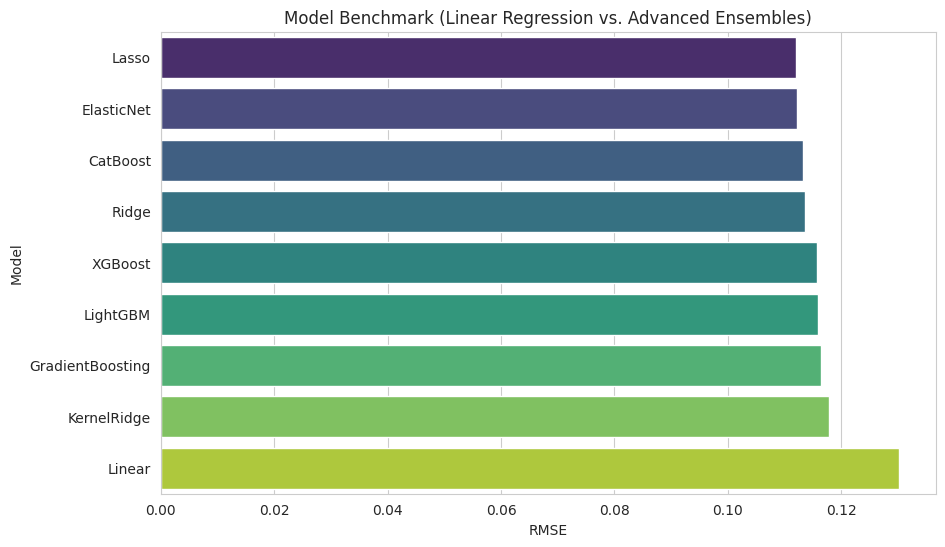

In [10]:
# 6.1 Define Models
models = [
    # Tier 1: Linear Models (with RobustScaler for outliers)
    ('Linear', make_pipeline(RobustScaler(), LinearRegression())),
    ('Lasso', make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=1))),
    ('Ridge', make_pipeline(RobustScaler(), Ridge(alpha=10, random_state=42))),
    ('ElasticNet', make_pipeline(RobustScaler(), ElasticNet(
        alpha=0.0005, l1_ratio=.9, random_state=3))),
    ('KernelRidge', KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)),

    # Tier 2: Tree-Based Models (No scaling needed)
    ('GradientBoosting', GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                                   max_depth=4, max_features='sqrt',
                                                   min_samples_leaf=15, min_samples_split=10,
                                                   loss='huber', random_state=5)),

    ('XGBoost', xgb.XGBRegressor(colsample_bytree=0.4603, gamma=0.0468,
                                 learning_rate=0.05, max_depth=3,
                                 min_child_weight=1.7817, n_estimators=2200,
                                 reg_alpha=0.4640, reg_lambda=0.8571,
                                 subsample=0.5213, random_state=7, nthread=-1)),

    ('LightGBM', lgb.LGBMRegressor(objective='regression', num_leaves=5,
                                   learning_rate=0.05, n_estimators=720,
                                   max_bin=55, bagging_fraction=0.8,
                                   bagging_freq=5, feature_fraction=0.2319,
                                   feature_fraction_seed=9, bagging_seed=9,
                                   min_data_in_leaf=6, min_sum_hessian_in_leaf=11,
                                   verbose=-1,
                                   silent=True)),

    ('CatBoost', CatBoostRegressor(iterations=6000, learning_rate=0.005,
                                   depth=4, l2_leaf_reg=3, loss_function='RMSE',
                                   verbose=0, random_state=42))
]

# 6.2 Run Benchmark
results = []
names = []
print(f"{'Model':<20} {'RMSE':<10}")
print("-" * 35)

for name, model in models:
    # Revert to this if produce wrong result
    # score = rmse_cv(model, X_train, y_train)
    # We pass X_train.values to avoid header issues with some libraries
    score = rmse_cv(model, X_train.values, y_train)
    results.append(score.mean())
    names.append(name)
    print(f"{name:<20} {score.mean():.4f}")

# 6.3 Visualize
benchmark_df = pd.DataFrame(
    {'Model': names, 'RMSE': results}).sort_values('RMSE')
plt.figure(figsize=(10, 6))
sns.barplot(data=benchmark_df, x='RMSE', y='Model', palette='viridis')
plt.title("Model Benchmark (Linear Regression vs. Advanced Ensembles)")
plt.show()

## 7. Ensemble Learning (Stacking & Blending)
To maximize predictive performance, we employ a two-stage ensemble strategy. First, we use a **Stacking Regressor**, where the predictions of base models (Lasso, ENet, Gradient Boosting, LightGBM) are fed into a meta-learner (XGBoost) to correct their biases. Finally, we apply **Geometric Blending** to combine the Stacking predictions with robust linear and boosting baselines, ensuring the model generalizes well to unseen data.

Model                RMSE       Status
---------------------------------------------
Linear               0.1301      (Done)
Lasso                0.1121      (Done)
Ridge                0.1136      (Done)
ElasticNet           0.1121      (Done)
KernelRidge          0.1178      (Done)
GradientBoosting     0.1163      (Done)
XGBoost              0.1157      (Done)
LightGBM             0.1159      (Done)
CatBoost             0.1133      (Done)
Stacking             0.1112      (Done)
Geometric_Blend      0.1094      (Done)

--- 🏆 Final Leaderboard ---
           Model  RMSE (Mean)  Std Dev
 Geometric_Blend       0.1094   0.0088
        Stacking       0.1112   0.0089
           Lasso       0.1121   0.0079
      ElasticNet       0.1121   0.0080
        CatBoost       0.1133   0.0077
           Ridge       0.1136   0.0092
         XGBoost       0.1157   0.0082
        LightGBM       0.1159   0.0081
GradientBoosting       0.1163   0.0106
     KernelRidge       0.1178   0.0085
          Linear 

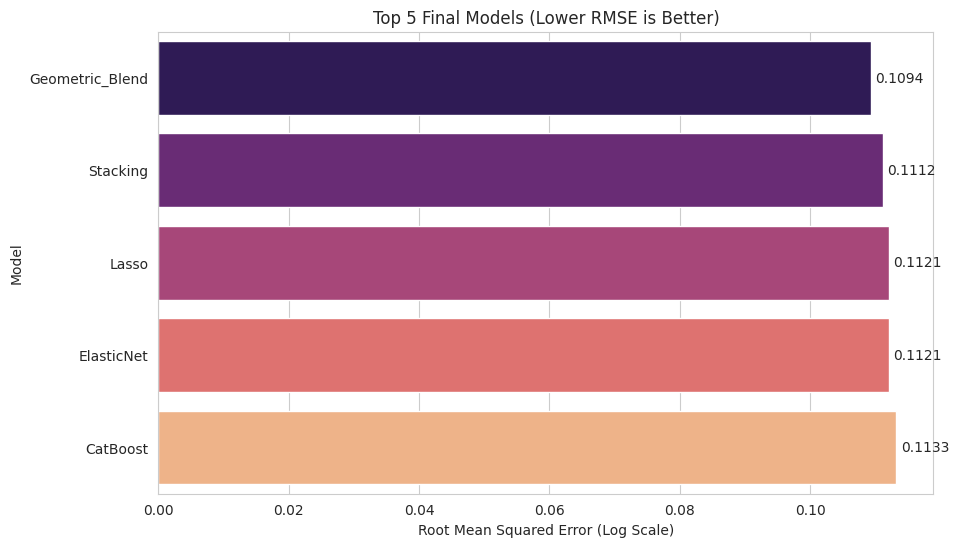

In [6]:
# -------------------------------------------------------------------------
# 7.1 Define Base Estimators & Meta Learner
# -------------------------------------------------------------------------
# Base: Lasso, ENet, GradientBoosting, LightGBM
# Meta: XGBoost

lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=1))
enet = make_pipeline(RobustScaler(), ElasticNet(
    alpha=0.0005, l1_ratio=.9, random_state=3))

gboost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                   max_depth=4, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=10,
                                   loss='huber', random_state=5)

lgb_model = lgb.LGBMRegressor(objective='regression', num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin=55, bagging_fraction=0.8,
                              bagging_freq=5, feature_fraction=0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf=6, min_sum_hessian_in_leaf=11,
                              verbose=-1)

xgb_meta = xgb.XGBRegressor(colsample_bytree=0.4603, gamma=0.0468,
                            learning_rate=0.05, max_depth=3,
                            min_child_weight=1.7817, n_estimators=2200,
                            reg_alpha=0.4640, reg_lambda=0.8571,
                            subsample=0.5213, random_state=7, nthread=-1)

# -------------------------------------------------------------------------
# 7.2 Build Stacking Regressor
# -------------------------------------------------------------------------
estimators = [
    ('lasso', lasso),
    ('enet', enet),
    ('gb', gboost),
    ('lgb', lgb_model)
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=xgb_meta,
    cv=5,
    n_jobs=-1
)

# -------------------------------------------------------------------------
# 7.3 Geometric Blending Setup
# -------------------------------------------------------------------------
# Helper to safely retrieve model definitions from the 'models' list in Section 6
def get_model_def(name):
    return [m for n, m in models if n == name][0]

# Retrieve unfitted definitions (Safe Lookup)
lasso_def = get_model_def('Lasso')
cat_def = get_model_def('CatBoost')

# Define the Blender
# Weights: 70% Stack, 15% CatBoost, 15% Lasso
blender_model = CustomGeometricBlender(
    model1=stack_model, w1=0.70, 
    model2=cat_def, w2=0.15, 
    model3=lasso_def, w3=0.15 
)

# -------------------------------------------------------------------------
# 7.4 Comprehensive Final Benchmarking
# -------------------------------------------------------------------------
# We create a final list to evaluate everything at once
final_models_to_evaluate = list(models) 
final_models_to_evaluate.append(('Stacking', stack_model))
final_models_to_evaluate.append(('Geometric_Blend', blender_model))

final_results = []
print(f"{'Model':<20} {'RMSE':<10} {'Status'}")
print("-" * 45)

for name, model in final_models_to_evaluate:
    # Skip models specifically if you want to save time, e.g., 'KernelRidge'
    # if name == 'KernelRidge': continue
    
    print(f"{name:<20} ...running CV", end='\r')
    
    # Use X_train.values to be safe with pipelines/stacking
    cv_scores = rmse_cv(model, X_train.values, y_train)
    
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    
    final_results.append({
        'Model': name,
        'RMSE (Mean)': mean_score,
        'Std Dev': std_score
    })
    
    print(f"{name:<20} {mean_score:.4f}      (Done)")

# -------------------------------------------------------------------------
# 7.5 Final Report & Visualization
# -------------------------------------------------------------------------
final_df = pd.DataFrame(final_results).sort_values(by='RMSE (Mean)')

print("\n--- 🏆 Final Leaderboard ---")
print(final_df.to_string(index=False, float_format='%.4f'))

# Visualize Top 5
plt.figure(figsize=(10, 6))
top_5 = final_df.head(5)
ax = sns.barplot(data=top_5, x='RMSE (Mean)', y='Model', palette='magma')
plt.title("Top 5 Final Models (Lower RMSE is Better)")
plt.xlabel("Root Mean Squared Error (Log Scale)")
# Add labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)
plt.show()

## 8. Final Prediction & Submission
We generate submission files for the Kaggle leaderboard.

In [7]:
# 8.1 Setup Directory
submission_dir = os.path.join("..", "submissions")
os.makedirs(submission_dir, exist_ok=True)
print(f"\n📂 Saving submissions to: {os.path.abspath(submission_dir)}")

# 8.2 Dictionary to store Log-Predictions
log_predictions = {}

# 8.3 Define Save Function


def train_and_save(model, name):
    """Fits model on full data, saves CSV, and stores log predictions."""
    print(f"Training & Generating for: {name}...")

    # A. Fit on FULL Training Data (Maximizes score accuracy)
    model.fit(X_train, y_train)

    # B. Predict (Log Scale)
    pred_log = model.predict(X_test)
    log_predictions[name] = pred_log

    # C. Inverse Transform (Real Price)
    pred_real = np.expm1(pred_log)

    # D. Save to CSV
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    filename = f"{timestamp}_{name}.csv"
    filepath = os.path.join(submission_dir, filename)

    sub = pd.DataFrame({'Id': test_ID, 'SalePrice': pred_real})
    sub.to_csv(filepath, index=False)
    print(f"  ✅ Saved: {filename}")

# --- EXECUTION PHASE ---


# 1. Generate for ALL Base Models (Loop through the list from Section 6)
print("\n--- 1. Generating Base Model Submissions ---")
for name, model in models:
    # We save all models for the full comparison table
    train_and_save(model, name)

# 2. Generate for Stacking Ensemble
print("\n--- 2. Generating Stacking Submission ---")
# stack_model is defined in Section 7
train_and_save(stack_model, "Stacking_Final")

# 3. Generate Geometric Mean Blend (Using Custom Estimator)
print("\n--- 3. Generating Geometric Blend ---")

try:
    # A. Retrieve UN-FITTED model definitions by name from the 'models' list
    # We use list comprehension to find the model object based on the name key
    stack_def = stack_model
    cat_def = [m for n, m in models if n == 'CatBoost'][0]
    lasso_def = [m for n, m in models if n == 'Lasso'][0]

    # B. Instantiate Custom Blender with weights (Defined as CustomGeometricBlender in Section 3)
    blender_model = CustomGeometricBlender(
        model1=stack_def, w1=0.70,
        model2=cat_def, w2=0.15,
        model3=lasso_def, w3=0.15
    )

    # C. Train and Save the final Blend Model
    # The train_and_save function will now call blender_model.fit()
    train_and_save(blender_model, "Geometric_Blend_Final")

except Exception as e:
    print(
        f"❌ Critical Error creating blend. Ensure CustomGeometricBlender is defined in Section 3 and all models are named correctly: {e}")

print("\nAll processes complete. Check your submissions folder!")


📂 Saving submissions to: /home/kakapt/code/python/house_price_analysis/submissions

--- 1. Generating Base Model Submissions ---
Training & Generating for: Linear...
  ✅ Saved: 2025-12-03_19-39_Linear.csv
Training & Generating for: Lasso...
  ✅ Saved: 2025-12-03_19-39_Lasso.csv
Training & Generating for: Ridge...
  ✅ Saved: 2025-12-03_19-39_Ridge.csv
Training & Generating for: ElasticNet...
  ✅ Saved: 2025-12-03_19-39_ElasticNet.csv
Training & Generating for: KernelRidge...
  ✅ Saved: 2025-12-03_19-39_KernelRidge.csv
Training & Generating for: GradientBoosting...
  ✅ Saved: 2025-12-03_19-40_GradientBoosting.csv
Training & Generating for: XGBoost...
  ✅ Saved: 2025-12-03_19-40_XGBoost.csv
Training & Generating for: LightGBM...
  ✅ Saved: 2025-12-03_19-40_LightGBM.csv
Training & Generating for: CatBoost...
  ✅ Saved: 2025-12-03_19-40_CatBoost.csv

--- 2. Generating Stacking Submission ---
Training & Generating for: Stacking_Final...
  ✅ Saved: 2025-12-03_19-40_Stacking_Final.csv

--- 3.

## 9. Deployment Preparation (Model & Artifact Serialization)

In [8]:
# 9.1 Setup "saved_models" Directory (One level up)
# This works on Windows (..\saved_models) and Linux (../saved_models)
model_dir = os.path.join("..", "saved_models")
os.makedirs(model_dir, exist_ok=True)
print(f"📂 Saving assets to: {os.path.abspath(model_dir)}")

# 9.2 Save Base Models
# We iterate through the list from Section 6 to save Linear, Lasso, Ridge, etc.
print("\n--- Saving Base Models ---")
for name, model in models:
    print(f"Serializing {name}...")
    # Retrain on full data to ensure it's the best version
    model.fit(X_train, y_train)
    # Save as [ModelName].pkl
    joblib.dump(model, os.path.join(model_dir, f"{name}.pkl"))

# 9.3 Save Stacking Model
print("\n--- Saving Stacking Ensemble ---")
stack_model.fit(X_train, y_train)
joblib.dump(stack_model, os.path.join(model_dir, "Stacking_Final.pkl"))

# 9.4 Save Preprocessing Artifacts
# The app needs these to know how to clean the data (Medians, Modes, Skewness)
print("\n--- Saving Artifacts ---")

# Identify skewed features robustly using pandas built-in .skew()
# This avoids the scipy type error by handling NaNs automatically
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
skewed_feats = all_data[numeric_feats].skew().sort_values(ascending=False)
skewness = pd.DataFrame({'Skew': skewed_feats})
skewed_features_list = skewness[abs(skewness) > 0.75].index.tolist()

artifacts = {
    # The exact column order the model expects
    "features": X_train.columns.tolist(),
    # For filling missing numbers
    "impute_medians": all_data.median(numeric_only=True).to_dict(),
    # For filling missing text
    "impute_modes": all_data.mode().iloc[0].to_dict(),
    "skewed_features": skewed_features_list,          # For Box-Cox transformation
    "lambda": 0.15                                    # Box-Cox Lambda value
}

joblib.dump(artifacts, os.path.join(model_dir, "artifacts.pkl"))

print(f"\n✅ Success! All models and artifacts saved to '{model_dir}'")

📂 Saving assets to: /home/kakapt/code/python/house_price_analysis/saved_models

--- Saving Base Models ---
Serializing Linear...
Serializing Lasso...
Serializing Ridge...
Serializing ElasticNet...
Serializing KernelRidge...
Serializing GradientBoosting...
Serializing XGBoost...
Serializing LightGBM...
Serializing CatBoost...

--- Saving Stacking Ensemble ---

--- Saving Artifacts ---

✅ Success! All models and artifacts saved to '../saved_models'
